In [1]:
import sys,os,glob,copy
sys.path.append('../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.interpolate import LinearNDInterpolator,interp2d, griddata
from itertools import product
import matplotlib as mpl
from matplotlib.colors import LogNorm
from IPython.display import display, Markdown
import glob

defaultPars = {'figure.figsize': (5, 4), 'lines.markersize' : 4, 'axes.titlesize' : 13, 'font.size' : 13,
               'axes.labelsize' : 16, 'xtick.labelsize' : 13, 'ytick.labelsize' : 13, 'legend.fontsize' : 10,
               "text.usetex": True, "font.family": "sans-serif", "font.sans-serif": ["Helvetica"],
               'font.family':'Times New Roman', 'font.serif':'Times New Roman', "savefig.dpi" : 300,
               'contour.linewidth' : 2.0, 'lines.linewidth' : 2.0, 'axes.grid' : True,
               'grid.linewidth' : 0.5, 'grid.color' : 'lightgray', 'axes.axisbelow' : True
               }
plt.rcParams.update(defaultPars) #Figure resolution
pd.set_option('display.max_rows', 200)

In [2]:
cmsCutflow = pd.read_pickle('../../CMS-EXO-20-004/AuxInfo/CMS-EXO-20-004-data/DMsimp_S3D_uR_CF_Monojet.pcl')

In [4]:
cmsCutflow.columns

Index(['$m_{med}$', '$m_{DM}$', '$\lambda$', 'Mode', 'Data-takingperiod',
       'Fullsample', 'Triggeremulation', '$p_{T}^{miss}>250$GeV',
       '$p_{T}^{miss}$qualityfilters', 'Electronveto', 'Muonveto', 'Tauveto',
       'Bjetveto', 'Photonveto', '$\Delta \phi (jet,p_{T}^{miss})>0.5$ rad',
       '$\Delta p_{T}^{miss}$ (PF-Cal)$<0.5$ rad',
       'LeadingAK4jet$p_{T}>100$GeV', 'LeadingAK4jet$\eta<2.4$',
       'LeadingAK4jetenergyfractions', 'Mono-Voverlapremoval',
       'HCALmitigation(jets)', 'HCALmitigation($\phi^{miss}$)',
       '$\Delta \phi (\mathrm{PF}_\mathrm{Charged})<2.0$ rad', 'Coupling'],
      dtype='object')

In [8]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&((cmsCutflow['$m_{med}$']==300)|(cmsCutflow['$m_{med}$']==500))
            &(cmsCutflow['Mode']=='DM+QCDjets')&(cmsCutflow['Data-takingperiod']==2017)].T

,32,172
$m_{med}$,500.0,300.0
$m_{DM}$,200.0,200.0
$\lambda$,1.0,1.0
Mode,DM+QCDjets,DM+QCDjets
Data-takingperiod,2017,2017
Fullsample,1.0,1.0
Triggeremulation,0.86888,0.51669
$p_{T}^{miss}>250$GeV,0.54465,0.096462
$p_{T}^{miss}$qualityfilters,0.54371,0.096312
Electronveto,0.54094,0.09546


In [13]:
pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_08/combined_norm_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,164134886.937178,200516760.15224,226067398.814389
bin_250.0_280.0_ErrorPlus,9866209.920197,10927240.544691,11622021.847118
bin_250.0_280.0_ErrorMinus,9866209.920197,10927240.544691,11622021.847118
bin_280.0_310.0,133363113.107726,149193345.837925,178354384.045134
bin_280.0_310.0_ErrorPlus,8937199.521176,9415794.047041,10307873.177428
bin_280.0_310.0_ErrorMinus,8937199.521176,9415794.047041,10307873.177428
bin_310.0_340.0,106146141.71981,95648166.528505,133862984.191269
bin_310.0_340.0_ErrorPlus,7963086.247341,7553282.819045,8923207.062565


In [12]:
pd.read_pickle('/home/ramos/MG5/dmsimpt_pptoxdxd_no_onshell_match/Events/run_09/combined_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,160126020.488143,183081725.335598,216862905.189991
bin_250.0_280.0_ErrorPlus,5311044.49496,5676205.101998,6180318.798515
bin_250.0_280.0_ErrorMinus,5311044.49496,5676205.101998,6180318.798515
bin_280.0_310.0,126136212.225556,142069999.52364,175748519.738674
bin_280.0_310.0_ErrorPlus,4714306.251545,5000971.62527,5574953.809843
bin_280.0_310.0_ErrorMinus,4714306.251545,5000971.62527,5574953.809843
bin_310.0_340.0,88725093.729615,111389854.458928,118358787.623882
bin_310.0_340.0_ErrorPlus,3955339.236607,4430417.931661,4561388.453093


In [3]:
cutflow = pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_01/scanResults_1j_nocut.pcl')

In [4]:
cutflow.T

,0,1,2,3,4,5,6,7,8,9,...,134,135,136,137,138,139,140,141,142,143
Coupling,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,...,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel,tchannel
Mode,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,...,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets,DM+QCDjets
$m_{med}$,100.0,100.0,100.0,100.0,100.0,100.0,300.0,300.0,300.0,300.0,...,2000.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0,2200.0
$m_{DM}$,1.0,1.0,1.0,75.0,75.0,75.0,1.0,1.0,1.0,200.0,...,500.0,1.0,1.0,1.0,200.0,200.0,200.0,350.0,350.0,350.0
Data-takingperiod,2018,2017,2016,2018,2017,2016,2018,2017,2016,2018,...,2016,2018,2017,2016,2018,2017,2016,2018,2017,2016
Luminosity (1/fb),59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,...,36.0,59.7,41.5,36.0,59.7,41.5,36.0,59.7,41.5,36.0
bin_250.0_280.0,222338.508712,147332.746737,150011.52395,133468.606405,129828.553503,91001.322549,22894.584139,20056.945542,16832.356226,9647.72722,...,3.473411,5.806697,5.847879,4.365318,7.029286,6.346586,4.930614,4.498866,4.220585,3.787705
bin_250.0_280.0_ErrorPlus,24404.821876,19866.343517,20046.133096,12725.732305,12550.999999,10507.927614,1215.11836,1137.32504,1041.896694,496.225543,...,0.21418,0.489012,0.490743,0.423997,0.421589,0.400593,0.353089,0.263728,0.255441,0.241988
bin_250.0_280.0_ErrorMinus,24404.821876,19866.343517,20046.133096,12725.732305,12550.999999,10507.927614,1215.11836,1137.32504,1041.896694,496.225543,...,0.21418,0.489012,0.490743,0.423997,0.421589,0.400593,0.353089,0.263728,0.255441,0.241988
bin_280.0_310.0,120544.974603,101793.534109,96435.979682,110414.938026,107988.236091,81294.51481,14639.635492,15026.58621,13349.799766,6125.541092,...,2.350825,5.188963,4.612412,3.788767,5.385748,3.69164,3.236506,3.493964,3.354824,2.968324


In [5]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==550)&(cmsCutflow['$m_{med}$']==750)].T

,76,100,135,164
$m_{med}$,750.0,750.0,750.0,750.0
$m_{DM}$,550.0,550.0,550.0,550.0
$\lambda$,1.0,1.0,1.0,1.0
Mode,DM+2QCDjets,DM+QCDjets,DM+2QCDjets,DM+QCDjets
Data-takingperiod,2018,2018,2017,2017
Fullsample,1.0,1.0,1.0,1.0
Triggeremulation,0.76326,0.83574,0.7745,0.84237
$p_{T}^{miss}>250$GeV,0.4081,0.47696,0.40654,0.47943
$p_{T}^{miss}$qualityfilters,0.40727,0.47642,0.40569,0.47858
Electronveto,0.40587,0.47349,0.40422,0.4753


In [6]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_36/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,211.499868,254.884456,289.953665
bin_250.0_280.0_ErrorPlus,8.744443,9.599504,10.23862
bin_250.0_280.0_ErrorMinus,8.744443,9.599504,10.23862
bin_280.0_310.0,173.176815,200.292183,228.492165
bin_280.0_310.0_ErrorPlus,7.912651,8.509599,9.08893
bin_280.0_310.0_ErrorMinus,7.912651,8.509599,9.08893
bin_310.0_340.0,129.792227,158.353747,182.576809
bin_310.0_340.0_ErrorPlus,6.850172,7.566435,8.124561


In [22]:
abs(0.3521-0.243947)/0.3521

0.3071655779608066

In [16]:
pd.read_pickle('../DMSimp_S3D_uR_2j_CMS-BPs_sample/Events/run_01/ys3u1_750_550_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,82.329394,93.359592,104.830997
bin_250.0_280.0_ErrorPlus,2.695343,2.872938,3.044015
bin_250.0_280.0_ErrorMinus,2.695343,2.872938,3.044015
bin_280.0_310.0,72.005129,85.064883,98.83057
bin_280.0_310.0_ErrorPlus,2.520684,2.739755,2.958397
bin_280.0_310.0_ErrorMinus,2.520684,2.739755,2.958397
bin_310.0_340.0,57.445269,68.1225,79.682147
bin_310.0_340.0_ErrorPlus,2.254913,2.451782,2.654591


In [24]:
abs(0.32266-0.315838)/0.32266

0.0211429988222897

In [17]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['$m_{med}$']==300)].T

,3
$m_{med}$,300.0
$m_{DM}$,200.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.51669
$p_{T}^{miss}>250$GeV,0.096462
$p_{T}^{miss}$qualityfilters,0.096312
Electronveto,0.09546


In [14]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_13/ys3u1_300_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,5895.833301,7274.080047,9647.72722
bin_250.0_280.0_ErrorPlus,387.917351,430.879315,496.225543
bin_250.0_280.0_ErrorMinus,387.917351,430.879315,496.225543
bin_280.0_310.0,4721.771258,5793.740949,6125.541092
bin_280.0_310.0_ErrorPlus,347.151527,384.544093,395.401977
bin_280.0_310.0_ErrorMinus,347.151527,384.544093,395.401977
bin_310.0_340.0,3394.570688,4109.217149,5206.709928
bin_310.0_340.0_ErrorPlus,294.346609,323.85168,364.542611


In [25]:
abs(0.0622-0.078455)/0.0622

0.2613344051446945

In [26]:
cmsCutflow[(cmsCutflow['$m_{DM}$']==200)&(cmsCutflow['$m_{med}$']==500)].T

,5
$m_{med}$,500.0
$m_{DM}$,200.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.86888
$p_{T}^{miss}>250$GeV,0.54465
$p_{T}^{miss}$qualityfilters,0.54371
Electronveto,0.54094


In [27]:
pd.read_pickle('../DMSimp_S3D_uR_1j_CMS-BPs_v2/Events/run_14/ys3u1_500_200_cms_exo_20_004.pcl').T

,0,1,2
Data-takingperiod,2016,2017,2018
Luminosity (1/fb),36.0,41.5,59.7
bin_250.0_280.0,3137.274777,4021.369924,4430.579677
bin_250.0_280.0_ErrorPlus,125.8945,142.533678,149.610045
bin_250.0_280.0_ErrorMinus,125.8945,142.533678,149.610045
bin_280.0_310.0,2601.765717,2854.36433,3511.120725
bin_280.0_310.0_ErrorPlus,114.647496,120.08401,133.1844
bin_280.0_310.0_ErrorMinus,114.647496,120.08401,133.1844
bin_310.0_340.0,2015.736934,2303.699353,2323.907242
bin_310.0_340.0_ErrorPlus,100.913067,107.880606,108.352734


In [28]:
abs(0.39732-0.221907)/0.39732

0.44149048625792814

In [6]:
year = 2017

cutflow = cutflow[cutflow['Data-takingperiod']==year]
cmsCutflow = cmsCutflow[cmsCutflow['Data-takingperiod']==year]

In [7]:
models = []
mCols = ['Mode','$m_{med}$','$m_{DM}$','$\lambda$','Data-takingperiod']
for row in cutflow[mCols].values:
    m = dict(zip(mCols,row.tolist()))
    if m not in models:
        models.append(m)
print('%i models loaded' %len(models))

48 models loaded


In [8]:
parameters = {label : list(set([m[label] for m in models])) for label in mCols}
for k,v in parameters.items():
    if len(v) == 1:
        parameters[k] = v[0]
print(parameters)

textstr = '\n'.join([r'%s = %s' %(k,v) for k,v in parameters.items() if k not in ['$m_{med}$','$m_{DM}$']])
print(textstr)

{'Mode': 'DM+QCDjets', '$m_{med}$': [1600.0, 100.0, 1000.0, 1800.0, 300.0, 750.0, 1200.0, 2000.0, 500.0, 1400.0, 2200.0], '$m_{DM}$': [800.0, 1.0, 900.0, 550.0, 200.0, 650.0, 75.0, 750.0, 400.0, 500.0, 600.0, 700.0, 350.0], '$\\lambda$': 1.0, 'Data-takingperiod': 2017}
Mode = DM+QCDjets
$\lambda$ = 1.0
Data-takingperiod = 2017


In [9]:
keys = list(cmsCutflow[mCols].columns.values)
i1 = cutflow.set_index(keys).index
i2 = cmsCutflow.set_index(keys).index
cutflow = cutflow[i1.isin(i2)]
cmsCutflow = cmsCutflow[i2.isin(i1)]
print(len(cutflow),len(cmsCutflow))

46 46


In [10]:
cutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)  
cmsCutflow.sort_values(['$m_{med}$','$m_{DM}$'],inplace=True,
                ascending=[True,True],ignore_index=True)

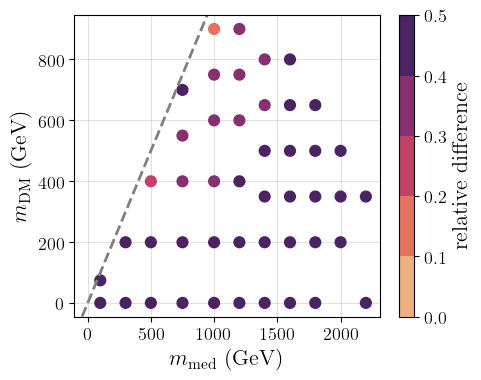

In [11]:
mmed = cutflow['$m_{med}$']
mDM = cutflow['$m_{DM}$']

relDiff = np.abs(cmsCutflow['HCALmitigation($\\phi^{miss}$)'] - cutflow['HCALmitigation($\\phi^{miss}$)'])/np.array(cmsCutflow['HCALmitigation($\\phi^{miss}$)'])

plt.scatter(x=mmed, y=mDM, c=relDiff, cmap=plt.get_cmap('flare', 5), vmin=0., vmax=0.5, s=60)
cbar = plt.colorbar(label=r'relative difference')
cbar.set_ticks([0.,0.1,0.2,0.3,0.4,0.5])
plt.axline((1, 1), slope=1, linestyle='--', color='gray')

plt.xlabel(r'$m_{\rm med}$ (GeV)')
plt.ylabel(r'$m_{\rm DM}$ (GeV)')

plt.tight_layout()
# plt.savefig('relDiff_eff_1j_default.png')

plt.show()

In [12]:
cutflow[(cutflow['$m_{med}$']==300)&(cutflow['$m_{DM}$']==200)].T

,3
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,300.0
$m_{DM}$,200.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7274.080047
bin_250.0_280.0_ErrorPlus,430.879315
bin_250.0_280.0_ErrorMinus,430.879315
bin_280.0_310.0,5793.740949


In [39]:
cutflow[(cutflow['$m_{med}$']==1000)&(cutflow['$m_{DM}$']==900)].T

,17
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1000.0
$m_{DM}$,900.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.086368
bin_250.0_280.0_ErrorPlus,0.254059
bin_250.0_280.0_ErrorMinus,0.254059
bin_280.0_310.0,6.02068


In [41]:
cmsCutflow[(cutflow['$m_{med}$']==100)&(cutflow['$m_{DM}$']==1)].T

,0
$m_{med}$,100.0
$m_{DM}$,1.0
$\lambda$,1.0
Mode,DM+QCDjets
Data-takingperiod,2017
Fullsample,1.0
Triggeremulation,0.047334
$p_{T}^{miss}>250$GeV,0.003092
$p_{T}^{miss}$qualityfilters,0.003092
Electronveto,0.003073


In [18]:
cutflow[(cutflow['$m_{med}$']==1800)&(cutflow['$m_{DM}$']==1)].T

,36
Coupling,tchannel
Mode,DM+QCDjets
$m_{med}$,1800.0
$m_{DM}$,1.0
Data-takingperiod,2017
Luminosity (1/fb),41.5
bin_250.0_280.0,7.812074
bin_250.0_280.0_ErrorPlus,0.36424
bin_250.0_280.0_ErrorMinus,0.36424
bin_280.0_310.0,6.470435
